# Power-sweep TLS saturation analysis

This notebook uses the original empirical power-sweep fit:

\[
rac{1}{Q_i(n)} = C_j^{P} + A_{m TLS,s}^{P}\,rac{	anh(h f_j/2 k_B T)}{\sqrt{1+(n/n_{c,s})^{eta}}}.
\]

Here the high-power offset/floor \(C_j^P\) is fit independently for each resonator, while \(A_{m TLS,s}^P\) and \(n_{c,s}\) are shared within a sample/wafer. This is intended as an empirical characterization of TLS saturation, not as a hard-constrained validation of the temperature-fit nuisance parameters.




In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import lsq_linear
from scipy import special

# Add the parent directory path to the system path
import sys
sys.path.append("../..")

# Optional display helper for notebooks
try:
    from IPython.display import display
except Exception:
    display = print

# ---------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------
from FilmStressed.data.curated_data import data_dict as stress_resonators

# Drop Sample N if present
stress_resonators = dict(stress_resonators)
stress_resonators.pop("Sample N", None)

# Optional: load temperature-fit results for the comparison plot.
# Expected object: fixed_results from your temperature-model notebook.
fixed_results = None
for candidate in ["fixed_results.pkl", "fixed_results.pickle", "fixed_results.npy"]:
    if os.path.exists(candidate):
        if candidate.endswith((".pkl", ".pickle")):
            with open(candidate, "rb") as f:
                fixed_results = pickle.load(f)
        elif candidate.endswith(".npy"):
            fixed_results = np.load(candidate, allow_pickle=True).item()
        print(f"Loaded {candidate}")
        break

if fixed_results is None:
    print("No fixed_results.pkl found. The power fits will run; the floor-comparison plot will be skipped unless fixed_results is loaded later.")

list(stress_resonators.keys())


No fixed_results.pkl found. The power fits will run; the floor-comparison plot will be skipped unless fixed_results is loaded later.


['Sample A', 'Sample B', 'Sample C', 'Sample D', 'Sample E', 'All Film']

In [2]:
# ---------------------------------------------------------------------
# Constants and helper functions
# ---------------------------------------------------------------------
h_SI = 6.62607015e-34
kB_SI = 1.380649e-23
kB = kB_SI
DEFAULT_F_RES = 5.5e9
T_BASE_POWER = 100.0  # mK
TC_NB = 9.2
GAMMA_NB = 1e-6


def _first_existing_key(d, keys):
    for k in keys:
        if k in d:
            return k
    return None


def has_temperature_data(sub):
    """True if resonator has enough temperature-sweep data to be part of the main T fit."""
    if not isinstance(sub, dict):
        return False
    required = ["Temp", "Qi_Temp", "Qi_Temp_err"]
    if not all(k in sub for k in required):
        return False
    try:
        return len(sub["Temp"]) >= 3 and len(sub["Qi_Temp"]) >= 3
    except Exception:
        return False


def tls_saturation_shape(n, log10_nc, beta=0.5):
    nc = 10.0**log10_nc
    n = np.asarray(n, dtype=float)
    return 1.0 / np.sqrt(1.0 + (np.maximum(n, 1e-30) / nc)**beta)


def tls_tanh_factor(T_mK, f_res):
    T_K = float(T_mK) * 1e-3
    x = h_SI * np.asarray(f_res, dtype=float) / (2 * kB_SI * max(T_K, 1e-12))
    return np.tanh(np.clip(x, 1e-12, 500))


def mb_loss_shape(T_mK, Tc, Gamma_ratio, f_res):
    """Same MB-like loss shape used in your temperature model."""
    T = np.asarray(T_mK, dtype=float) * 1e-3
    f = np.asarray(f_res, dtype=float)
    T = np.maximum(T, 1e-9)

    D0 = 1.764 * kB_SI * Tc
    hw = h_SI * f
    Gamma = Gamma_ratio * D0

    rat = Tc / T
    D_bcs = np.where(
        rat > 1,
        D0 * np.tanh(1.74 * np.sqrt(np.clip(rat - 1, 0, None))),
        0.0,
    )

    D = np.sqrt(D_bcs**2 + Gamma**2)

    eta = np.clip(hw / (2 * kB_SI * T), 1e-12, 500)
    dkT = np.clip(D / (kB_SI * T), 0, 500)

    s1_th = (4 * D / hw) * np.exp(-dkT) * np.sinh(eta) * special.k0(eta)
    s1_dy = (Gamma / np.maximum(D, 1e-30))**2
    s1 = np.minimum(s1_th + s1_dy, 1.0)

    s2 = (np.pi * D / hw) * np.tanh(np.clip(D / (2 * kB_SI * T), 1e-12, 500))

    return s1 / np.maximum(s2, 1e-30)


def _param_value(params, kind, name, default=np.nan):
    q = params[(params["kind"] == kind) & (params["name"] == name)]
    return float(q["value"].iloc[0]) if len(q) else default


In [3]:
# ---------------------------------------------------------------------
# Helper: robustly extract sample stress from a power_results entry
# ---------------------------------------------------------------------

def _result_stress(result):
    """
    Return one scalar stress value from a power_results[sample] dict.
    Works whether stress is stored at top level or inside result["data"].
    """

    import numpy as np

    if "stress" in result:
        val = result["stress"]
    elif "data" in result and "stress" in result["data"].columns:
        val = result["data"]["stress"]
    elif "df" in result and "stress" in result["df"].columns:
        val = result["df"]["stress"]
    else:
        return np.nan

    if hasattr(val, "dropna"):
        val = val.dropna()
        return float(val.iloc[0]) if len(val) else np.nan

    arr = np.asarray(val).ravel()
    arr = arr[np.isfinite(arr)]
    return float(arr[0]) if len(arr) else np.nan

In [4]:
# ---------------------------------------------------------------------
# Build power dataframe, filtering out resonators without temperature data
# ---------------------------------------------------------------------
def build_power_df(
    stress_resonators,
    n_min=1,
    n_max=1e8,
    loss_frac_floor=0.10,
    require_temperature_data=True,
    verbose=True,
):
    rows = []
    skipped = []

    for sample, chip in stress_resonators.items():
        if not isinstance(chip, dict):
            continue

        stress = chip.get("stress", np.nan)
        stress_err = chip.get("stress_err", np.nan)

        for label, sub in chip.items():
            if not isinstance(sub, dict):
                continue

            if require_temperature_data and not has_temperature_data(sub):
                skipped.append((sample, label, "no temperature data"))
                continue

            k_n = _first_existing_key(sub, ["Num_Photon", "n", "n_photon", "Photon_Number"])
            k_q = _first_existing_key(sub, ["Qi_Power", "Qi", "Power_Qi"])
            k_qe = _first_existing_key(sub, ["Qi_Power_err", "Qi_err", "Power_Qi_err"])

            if k_n is None or k_q is None or k_qe is None:
                skipped.append((sample, label, "missing power keys"))
                continue

            n = np.asarray(sub[k_n], dtype=float)
            Q = np.asarray(sub[k_q], dtype=float)
            Qerr = np.asarray(sub[k_qe], dtype=float)
            m = min(len(n), len(Q), len(Qerr))
            n, Q, Qerr = n[:m], Q[:m], Qerr[:m]

            if "Freq" in sub and len(sub["Freq"]) > 0:
                f_res = float(np.nanmedian(np.asarray(sub["Freq"], dtype=float)))
            elif "Power_Freq" in sub and len(sub["Power_Freq"]) > 0:
                f_res = float(np.nanmedian(np.asarray(sub["Power_Freq"], dtype=float)))
            else:
                f_res = DEFAULT_F_RES

            good = (
                np.isfinite(n)
                & np.isfinite(Q)
                & np.isfinite(Qerr)
                & (n >= n_min)
                & (n <= n_max)
                & (Q > 0)
                & (Qerr > 0)
            )

            if np.sum(good) < 3:
                skipped.append((sample, label, f"only {np.sum(good)} good power points"))
                continue

            for ni, qi, qerri in zip(n[good], Q[good], Qerr[good]):
                invQ = 1.0 / qi
                invQ_err_stat = qerri / qi**2
                invQ_err_eff = np.sqrt(invQ_err_stat**2 + (loss_frac_floor * invQ)**2)

                rows.append({
                    "sample": sample,
                    "label": label,
                    "res_id": f"{sample}::{label}",
                    "stress": stress,
                    "stress_err": stress_err,
                    "n": ni,
                    "Qi": qi,
                    "Qi_err": qerri,
                    "invQ": invQ,
                    "invQ_err": invQ_err_eff,
                    "invQ_err_stat": invQ_err_stat,
                    "f_res": f_res,
                })

    df = pd.DataFrame(rows)

    if verbose:
        print(f"Built power_df with {len(df)} points and {df['res_id'].nunique() if len(df) else 0} resonators")
        if len(df):
            display(df.groupby(["sample", "label"]).size().rename("npts").reset_index())
        if skipped:
            print(f"Skipped {len(skipped)} resonator entries; first few:")
            for item in skipped[:12]:
                print("  ", item)

    return df


power_df = build_power_df(
    stress_resonators,
    n_min=1,
    n_max=1e8,
    loss_frac_floor=0.10,
    require_temperature_data=True,
    verbose=True,
)

power_df.head()


Built power_df with 340 points and 17 resonators


,sample,label,npts
0,Sample A,Res2,16
1,Sample A,Res3,16
2,Sample A,Res4,14
3,Sample B,Res1,34
4,Sample B,Res2,17
5,Sample B,Res3,17
6,Sample B,Res4,17
7,Sample C,Res1,22
8,Sample C,Res2,21
9,Sample C,Res3,21


Skipped 9 resonator entries; first few:
   ('Sample A', 'Res1_NoTemp', 'no temperature data')
   ('Sample B', 'Res5_NoTemp', 'no temperature data')
   ('Sample B', 'Res6_NoTemp', 'no temperature data')
   ('Sample D', 'Res5_NoTemp', 'no temperature data')
   ('Sample D', 'Res6_NoTemp', 'no temperature data')
   ('Sample D', 'Res7_NoTemp', 'no temperature data')
   ('Sample D', 'Res8_NoTemp', 'no temperature data')
   ('All Film', 'XRD', 'no temperature data')
   ('All Film', 'Transport', 'no temperature data')


,sample,label,res_id,stress,stress_err,n,Qi,Qi_err,invQ,invQ_err,invQ_err_stat,f_res
0,Sample A,Res2,Sample A::Res2,-734.0,70,1.21,100031.31,17494.90,0.000010,2.014016e-06,1.748395e-06,5.456676e+09
1,Sample A,Res2,Sample A::Res2,-734.0,70,2.47,103682.77,15877.18,0.000010,1.763958e-06,1.476931e-06,5.456676e+09
2,Sample A,Res2,Sample A::Res2,-734.0,70,4.53,96314.35,10261.44,0.000010,1.517114e-06,1.106181e-06,5.456676e+09
3,Sample A,Res2,Sample A::Res2,-734.0,70,13.40,140906.04,13929.51,0.000007,9.979364e-07,7.015791e-07,5.456676e+09
4,Sample A,Res2,Sample A::Res2,-734.0,70,19.70,105207.29,8261.01,0.000010,1.208509e-06,7.463482e-07,5.456676e+09


In [5]:
# ---------------------------------------------------------------------
# Original empirical TLS-saturation power fit
# ---------------------------------------------------------------------
def fit_tls_power_model_profile(
    df_s,
    beta=0.5,
    log10_nc_grid=np.linspace(-4, 8, 501),
):
    """
    Model:
        1/Q_i(n,j) = C_j + A_TLS * tanh(hf/2kT) / sqrt(1 + (n/nc)^beta)

    For each fixed n_c, C_j and A_TLS are solved by bounded linear least squares.
    Then profile over n_c.
    """
    y = df_s["invQ"].to_numpy(float)
    err = df_s["invQ_err"].to_numpy(float)
    nphot = df_s["n"].to_numpy(float)
    f_res = df_s["f_res"].to_numpy(float)

    res_ids = sorted(df_s["res_id"].unique())
    res_index = {r: i for i, r in enumerate(res_ids)}
    n_res = len(res_ids)

    best = None
    profile_rows = []

    for log10_nc in log10_nc_grid:
        sat = tls_saturation_shape(nphot, log10_nc, beta=beta)
        th = tls_tanh_factor(T_BASE_POWER, f_res)
        tls_shape = th * sat

        # columns: one baseline C_j per resonator, plus one shared TLS amplitude A_TLS
        X = np.zeros((len(df_s), n_res + 1))
        for row_i, r in enumerate(df_s["res_id"]):
            X[row_i, res_index[r]] = 1.0
        X[:, -1] = tls_shape

        Xw = X / err[:, None]
        yw = y / err

        sol = lsq_linear(Xw, yw, bounds=(0, np.inf), method="trf")
        yfit = X @ sol.x
        chi2 = float(np.sum(((y - yfit) / err)**2))

        row = {
            "log10_nc": float(log10_nc),
            "nc": float(10.0**log10_nc),
            "chi2": chi2,
            "success": bool(sol.success),
            "params": sol.x,
            "yfit": yfit,
        }
        profile_rows.append(row)

        if best is None or chi2 < best["chi2"]:
            best = row

    profile = pd.DataFrame([
        {"log10_nc": r["log10_nc"], "nc": r["nc"], "chi2": r["chi2"]}
        for r in profile_rows
    ])
    profile["delta_chi2"] = profile["chi2"] - profile["chi2"].min()

    within_1sigma = profile[profile["delta_chi2"] <= 1.0]
    if len(within_1sigma) > 0:
        log_nc_lo = float(within_1sigma["log10_nc"].min())
        log_nc_hi = float(within_1sigma["log10_nc"].max())
    else:
        log_nc_lo = np.nan
        log_nc_hi = np.nan

    best_params = best["params"]
    npts = len(y)
    k = n_res + 2  # C_j per resonator + A_TLS + log10_nc
    dof = max(npts - k, 1)

    return {
        "model": "empirical_tls_saturation_free_offset",
        "success": bool(best["success"]),
        "beta": beta,
        "log10_nc": best["log10_nc"],
        "nc": best["nc"],
        "log10_nc_1sigma": (log_nc_lo, log_nc_hi),
        "nc_1sigma": (10.0**log_nc_lo, 10.0**log_nc_hi),
        "A_TLS": float(best_params[-1]),
        "C_res": dict(zip(res_ids, best_params[:-1])),
        "res_ids": res_ids,
        "yfit": best["yfit"],
        "chi2": best["chi2"],
        "chi2_red": best["chi2"] / dof,
        "npts": npts,
        "k": k,
        "dof": dof,
        "profile": profile,
        "profile_at_boundary": (
            np.isclose(best["log10_nc"], log10_nc_grid[0])
            or np.isclose(best["log10_nc"], log10_nc_grid[-1])
        ),
    }


def fit_power_sweeps_by_sample(power_df, beta=0.5, log10_nc_grid=np.linspace(-4, 8, 501)):
    results = {}
    rows = []

    for sample, df_s in power_df.groupby("sample"):
        if len(df_s) < 5:
            continue

        tls = fit_tls_power_model_profile(df_s, beta=beta, log10_nc_grid=log10_nc_grid)
        results[sample] = {"data": df_s.copy(), "tls_saturation": tls}

        rows.append({
            "sample": sample,
            "stress": df_s["stress"].iloc[0],
            "stress_err": df_s["stress_err"].iloc[0],
            "npts": len(df_s),
            "n_res": df_s["res_id"].nunique(),
            "n_min": df_s["n"].min(),
            "n_max": df_s["n"].max(),
            "nc_best": tls["nc"],
            "log10_nc_best": tls["log10_nc"],
            "nc_1sigma_low": tls["nc_1sigma"][0],
            "nc_1sigma_high": tls["nc_1sigma"][1],
            "A_TLS": tls["A_TLS"],
            "chi2_tls": tls["chi2"],
            "chi2_red_tls": tls["chi2_red"],
            "nc_at_boundary": tls["profile_at_boundary"],
        })

    summary = pd.DataFrame(rows).sort_values("stress")
    return summary, results


power_summary, power_results = fit_power_sweeps_by_sample(
    power_df,
    beta=0.5,
    log10_nc_grid=np.linspace(-4, 8, 501),
)

display(power_summary)


,sample,stress,stress_err,npts,n_res,n_min,n_max,nc_best,log10_nc_best,nc_1sigma_low,nc_1sigma_high,A_TLS,chi2_tls,chi2_red_tls,nc_at_boundary
0,Sample A,-734.0,70,46,3,1.21,70900.0,0.015276,-1.816,0.000100,8.790225,1.172449e-05,14.712916,0.358852,False
1,Sample B,-535.0,50,85,4,19.70,2720000.0,772.680585,2.888,255.858589,2208.004733,3.641224e-07,9.853223,0.124724,False
2,Sample C,-368.0,30,64,3,1.08,11300000.0,0.301995,-0.520,0.089536,0.731139,1.832466e-06,12.913676,0.218876,False
3,Sample D,-41.0,30,84,4,1.20,6950000.0,0.963829,-0.016,0.444631,1.770109,1.933138e-06,27.191571,0.348610,False
4,Sample E,62.5,43,61,3,1.84,5630000.0,0.010965,-1.960,0.000100,0.285759,4.329663e-06,18.448954,0.329446,False


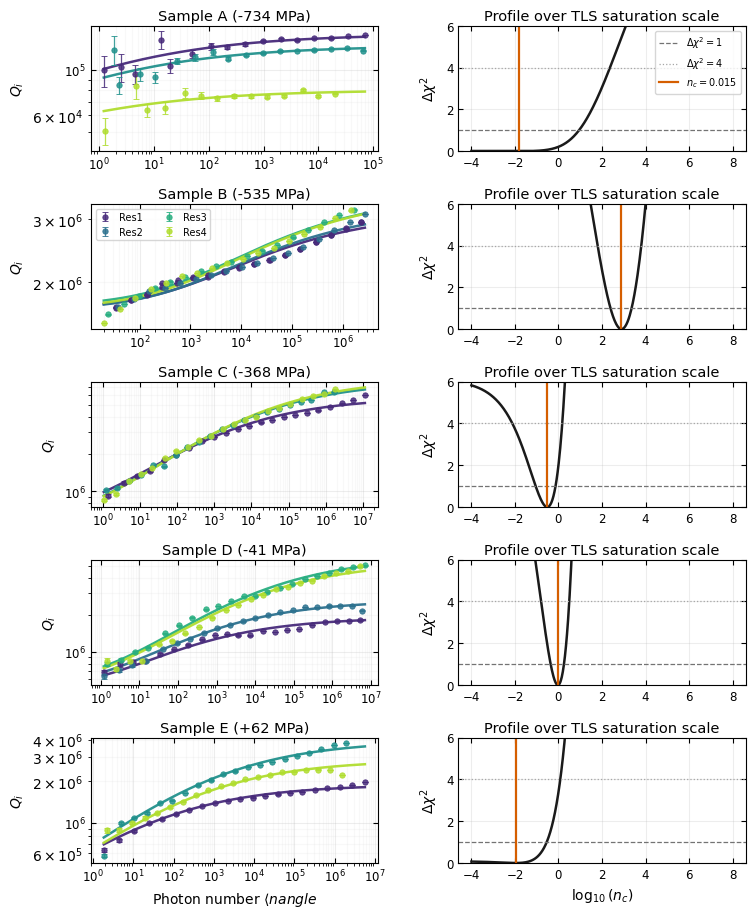

In [6]:
# ---------------------------------------------------------------------
# Nice plot: 5-panel sample-by-sample power fits + nc profile
# ---------------------------------------------------------------------


def plot_power_sweep_fits_paper(
    power_results,
    figsize=(7.4, 9.2),
    cmap_name="viridis",
    n_fit_points=1000,
    plot_loss=False,
    show_profiles=True,
    savepath=None,
):
    samples = sorted(
        power_results.keys(),
        key=lambda s: _result_stress(power_results[s]),
    )

    n_samples = len(samples)
    ncols = 2 if show_profiles else 1

    fig, axs = plt.subplots(
        n_samples,
        ncols,
        figsize=figsize,
        squeeze=False,
        constrained_layout=False,
    )

    cmap = mpl.colormaps[cmap_name]

    title_fs = 10.5
    label_fs = 10
    tick_fs = 8.5
    legend_fs = 7.0

    for i, sample in enumerate(samples):
        result = power_results[sample]
        df_s = result["data"]
        tls = result["tls_saturation"]

        ax = axs[i, 0]
        axp = axs[i, 1] if show_profiles else None

        res_groups = list(df_s.groupby("res_id"))
        colors = cmap(np.linspace(0.12, 0.88, len(res_groups)))

        nplot = np.logspace(
            np.log10(df_s["n"].min()),
            np.log10(df_s["n"].max()),
            n_fit_points,
        )

        for color, (res_id, df_r) in zip(colors, res_groups):
            df_r = df_r.sort_values("n")
            label = res_id.split("::")[-1]

            Cj = tls["C_res"][res_id]
            A = tls["A_TLS"]
            f_res = df_r["f_res"].median()
            th = tls_tanh_factor(T_BASE_POWER, f_res)

            y_invQ_fit = Cj + A * th * tls_saturation_shape(
                nplot,
                np.log10(tls["nc"]),
                beta=tls["beta"],
            )

            if plot_loss:
                y_data = df_r["invQ"]
                y_err = df_r["invQ_err"]
                y_fit = y_invQ_fit
                ylabel = r"$1/Q_i$"
            else:
                y_data = df_r["Qi"]
                y_err = df_r["Qi_err"]
                y_fit = 1.0 / y_invQ_fit
                ylabel = r"$Q_i$"

            ax.errorbar(
                df_r["n"],
                y_data,
                yerr=y_err,
                fmt="o",
                ms=3.8,
                capsize=2.0,
                color=color,
                ecolor=color,
                elinewidth=0.9,
                markeredgewidth=0.7,
                alpha=0.85,
                label=label,
                zorder=5,
            )

            ax.plot(
                nplot,
                y_fit,
                "-",
                lw=1.8,
                color=color,
                alpha=0.95,
                zorder=4,
            )

        stress = df_s["stress"].iloc[0]
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(f"{sample} ({stress:+.0f} MPa)", fontsize=title_fs, pad=4)
        ax.set_ylabel(ylabel, fontsize=label_fs)
        ax.grid(True, which="major", alpha=0.22)
        ax.grid(True, which="minor", alpha=0.08)
        ax.tick_params(axis="both", labelsize=tick_fs, direction="in", top=True, right=True)

        if i == n_samples - 1:
            ax.set_xlabel(r"Photon number $\langle nangle$", fontsize=label_fs)

        # Put legend on Sample B if present; otherwise first row.
        if sample == "Sample B" or ("Sample B" not in samples and i == 0):
            ax.legend(
                fontsize=legend_fs,
                ncol=2,
                frameon=True,
                handlelength=1.3,
                borderpad=0.35,
                loc="best",
            )

        if show_profiles:
            profile = tls["profile"]
            axp.plot(profile["log10_nc"], profile["delta_chi2"], color="0.1", lw=1.8)
            axp.axhline(1, color="0.45", ls="--", lw=0.9, label=r"$\Delta\chi^2=1$")
            axp.axhline(4, color="0.65", ls=":", lw=0.9, label=r"$\Delta\chi^2=4$")
            axp.axvline(np.log10(tls["nc"]), color="#D55E00", lw=1.6, label=rf"$n_c={tls['nc']:.2g}$")
            axp.set_ylim(0, 6)
            axp.set_ylabel(r"$\Delta\chi^2$", fontsize=label_fs)
            axp.set_title("Profile over TLS saturation scale", fontsize=title_fs, pad=4)
            axp.grid(alpha=0.22)
            axp.tick_params(axis="both", labelsize=tick_fs, direction="in", top=True, right=True)
            if i == n_samples - 1:
                axp.set_xlabel(r"$\log_{10}(n_c)$", fontsize=label_fs)
            if i == 0:
                axp.legend(fontsize=legend_fs, frameon=True, loc="best")

    fig.subplots_adjust(
        left=0.10,
        right=0.985,
        bottom=0.07,
        top=0.98,
        wspace=0.28,
        hspace=0.42,
    )

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig


fig = plot_power_sweep_fits_paper(
    power_results,
    figsize=(7.4, 9.2),
    cmap_name="viridis",
    plot_loss=False,
    show_profiles=True,
    savepath="power_tls_saturation_fits.png",
)
plt.show()


In [7]:
# ---------------------------------------------------------------------
# Compare power-fit high-power floors to temperature-fit non-TLS floors
# ---------------------------------------------------------------------
def build_floor_comparison_df(power_results, fixed_results, T_base_mK=100.0):
    if fixed_results is None:
        raise ValueError("fixed_results is None. Load fixed_results.pkl first to make this comparison.")

    loss_fit = fixed_results["loss_profile"]["best_fit"]
    params = loss_fit["params"]
    Tc2 = loss_fit["Tc2"]
    Gamma = loss_fit["Gamma"]

    rows = []
    for sample, result in power_results.items():
        df_s = result["data"]
        tls = result["tls_saturation"]
        A_sec = _param_value(params, "A_secondary", sample, default=np.nan)

        for res_id, C_power in tls["C_res"].items():
            df_r = df_s[df_s["res_id"] == res_id]
            if len(df_r) == 0:
                continue

            f_res = float(df_r["f_res"].median())
            stress = float(df_r["stress"].iloc[0])
            stress_err = float(df_r["stress_err"].iloc[0]) if "stress_err" in df_r else np.nan

            C_temp = _param_value(params, "C_res", res_id, default=np.nan)
            g_sec = mb_loss_shape(T_base_mK, Tc2, Gamma, f_res)
            g_nb = mb_loss_shape(T_base_mK, TC_NB, GAMMA_NB, f_res)
            floor_temp = C_temp + A_sec * g_sec + g_nb

            rows.append({
                "sample": sample,
                "label": res_id.split("::")[-1],
                "res_id": res_id,
                "stress": stress,
                "stress_err": stress_err,
                "f_res": f_res,
                "C_power": C_power,
                "C_temp": C_temp,
                "A_sec_temp": A_sec,
                "g_sec_100mK": g_sec,
                "g_nb_100mK": g_nb,
                "floor_temp_model": floor_temp,
                "ratio_power_to_temp_floor": C_power / floor_temp if np.isfinite(floor_temp) and floor_temp > 0 else np.nan,
                "delta_power_minus_temp_floor": C_power - floor_temp,
            })

    out = pd.DataFrame(rows)
    out = out[np.isfinite(out["C_power"]) & np.isfinite(out["floor_temp_model"]) & (out["floor_temp_model"] > 0)].copy()
    return out.sort_values(["stress", "sample", "label"])


def plot_floor_comparison(floor_df, figsize=(3.6, 3.3), cmap_name="plasma", savepath=None):
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    stress_vals = floor_df["stress"].to_numpy(float)
    norm = mpl.colors.Normalize(vmin=np.nanmin(stress_vals), vmax=np.nanmax(stress_vals))
    cmap = mpl.colormaps[cmap_name]

    for _, row in floor_df.iterrows():
        ax.errorbar(
            row["floor_temp_model"],
            row["C_power"],
            fmt="o",
            ms=5.5,
            color=cmap(norm(row["stress"])),
            alpha=0.9,
        )

    x = floor_df["floor_temp_model"].to_numpy(float)
    y = floor_df["C_power"].to_numpy(float)
    lo = min(np.nanmin(x), np.nanmin(y)) * 0.7
    hi = max(np.nanmax(x), np.nanmax(y)) * 1.4
    ax.plot([lo, hi], [lo, hi], "--", color="0.35", lw=1.0, label="1:1")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel(r"Temperature-fit non-TLS floor")
    ax.set_ylabel(r"Power-fit high-power floor $C_j^P$")
    ax.grid(True, which="major", alpha=0.22)
    ax.grid(True, which="minor", alpha=0.10)
    ax.tick_params(direction="in", top=True, right=True, labelsize=9)
    ax.legend(fontsize=8, frameon=True, loc="best")

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Stress [MPa]")
    cbar.ax.tick_params(labelsize=8)

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig


if fixed_results is not None:
    floor_comparison_df = build_floor_comparison_df(power_results, fixed_results, T_base_mK=100.0)
    display(floor_comparison_df)

    fig = plot_floor_comparison(
        floor_comparison_df,
        figsize=(3.6, 3.3),
        cmap_name="plasma",
        savepath="power_floor_vs_temperature_floor.png",
    )
    plt.show()
else:
    print("Skipping floor comparison: fixed_results is not loaded.")


Skipping floor comparison: fixed_results is not loaded.


In [8]:
# ---------------------------------------------------------------------
# Useful summary table for appendix text
# ---------------------------------------------------------------------
summary_cols = [
    "sample", "stress", "npts", "n_res", "n_min", "n_max",
    "nc_best", "nc_1sigma_low", "nc_1sigma_high",
    "A_TLS", "chi2_red_tls", "nc_at_boundary",
]
display(power_summary[summary_cols])


,sample,stress,npts,n_res,n_min,n_max,nc_best,nc_1sigma_low,nc_1sigma_high,A_TLS,chi2_red_tls,nc_at_boundary
0,Sample A,-734.0,46,3,1.21,70900.0,0.015276,0.000100,8.790225,1.172449e-05,0.358852,False
1,Sample B,-535.0,85,4,19.70,2720000.0,772.680585,255.858589,2208.004733,3.641224e-07,0.124724,False
2,Sample C,-368.0,64,3,1.08,11300000.0,0.301995,0.089536,0.731139,1.832466e-06,0.218876,False
3,Sample D,-41.0,84,4,1.20,6950000.0,0.963829,0.444631,1.770109,1.933138e-06,0.348610,False
4,Sample E,62.5,61,3,1.84,5630000.0,0.010965,0.000100,0.285759,4.329663e-06,0.329446,False


In [9]:
# ---------------------------------------------------------------------
# Paper-style 5-column power-sweep fits only
# ---------------------------------------------------------------------
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 10,
})

def plot_power_sweep_fits_5col(
    power_results,
    figsize=(16, 4),
    cmap_name="viridis",
    n_fit_points=1000,
    plot_loss=False,
    savepath=None,
):
    samples = sorted(
        power_results.keys(),
        key=lambda s: _result_stress(power_results[s]),
    )

    n_samples = len(samples)

    fig, axs = plt.subplots(
        1,
        n_samples,
        figsize=figsize,
        sharey=True,
        squeeze=False,
        constrained_layout=False,
    )

    axs = axs[0]

    cmap = mpl.colormaps[cmap_name]

    freqs = []
    for sample in samples:
        for freq in power_results[sample]['data']['f_res'].unique():
            freqs.append(freq)
    f_min = np.min(freqs)
    f_max = np.max(freqs)
    print(f_min, f_max)
    

    title_fs = 13
    label_fs = 16
    tick_fs = 10
    legend_fs = 9

    for i, sample in enumerate(samples):
        result = power_results[sample]
        df_s = result["data"]
        tls = result["tls_saturation"]

        ax = axs[i]

        res_groups = list(df_s.groupby("res_id"))
        # colors = cmap(np.linspace(0.12, 0.88, len(res_groups)))

        freqs = df_s['f_res'].unique()
        colors = cmap(0.12 + 0.76 * (freqs - f_min) / (f_max - f_min))

        margine = 2
        nplot = np.logspace(
            np.log10(df_s["n"].min()/margine),
            np.log10(margine*df_s["n"].max()),
            n_fit_points,
        )

        for color, (res_id, df_r) in zip(colors, res_groups):
            df_r = df_r.sort_values("n")
            label = res_id.split("::")[-1]

            Cj = tls["C_res"][res_id]
            A = tls["A_TLS"]
            f_res = df_r["f_res"].median()
            th = tls_tanh_factor(T_BASE_POWER, f_res)

            y_invQ_fit = Cj + A * th * tls_saturation_shape(
                nplot,
                np.log10(tls["nc"]),
                beta=tls["beta"],
            )

            if plot_loss:
                y_data = df_r["invQ"]
                y_err = df_r["invQ_err"]
                y_fit = y_invQ_fit
                ylabel = r"$1/Q_i$"
            else:
                y_data = df_r["Qi"]
                y_err = df_r["Qi_err"]
                y_fit = 1.0 / y_invQ_fit
                ylabel = r"$Q_i$"

            ax.errorbar(
                df_r["n"],
                y_data,
                yerr=y_err,
                fmt="o",
                ms=3.5,
                capsize=2.0,
                color=color,
                ecolor=color,
                elinewidth=0.9,
                markeredgewidth=0.7,
                alpha=0.85,
                label=label,
                zorder=5,
            )

            ax.plot(
                nplot,
                y_fit,
                "-",
                lw=2.0,
                color=color,
                alpha=0.95,
                zorder=4,
            )

        stress = df_s["stress"].iloc[0]
        stress_err = df_s["stress_err"].iloc[0]

        stress_label = f'{stress:.0f}$\\pm${stress_err:.0f}$\\,$MPa'.replace('-', '$-$')
        ax.set_title(stress_label, fontsize=title_fs, pad=6)

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, which="major", alpha=0.22)
        ax.grid(True, which="minor", alpha=0.08)

        ax.tick_params(
            axis="both",
            labelsize=tick_fs,
            direction="in",
            top=True,
            right=True,
        )

        ax.set_xlabel(
            r"Photon number $\langle n\rangle$",
            fontsize=label_fs,
        )

        if i == 0:
            ax.set_ylabel(ylabel, fontsize=label_fs)
        Qi_all = []

        for sample in power_results.values():
            Qi_all.extend(sample["data"]["Qi"])
        
        Qi_all = np.asarray(Qi_all)
        if plot_loss:
            ymin = 0.8*np.nanmin(1/Qi_all)
            ymax = 1.2*np.nanmax(1/Qi_all)
        else:
            ymin = 0.8*np.nanmin(Qi_all)
            ymax = 1.2*np.nanmax(Qi_all)

        ax.set_xlim(df_s["n"].min()/margine, margine*df_s["n"].max())
        ax.set_ylim(ymin, ymax)


    fig.subplots_adjust(
        left=0.06,
        right=0.995,
        bottom=0.11,
        top=0.82,
        wspace=0.28,
        hspace=0.25,
    )

    fig.tight_layout(pad=0.4, w_pad=.75, h_pad=1.0)

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig

4231876180.0 6265521980.0


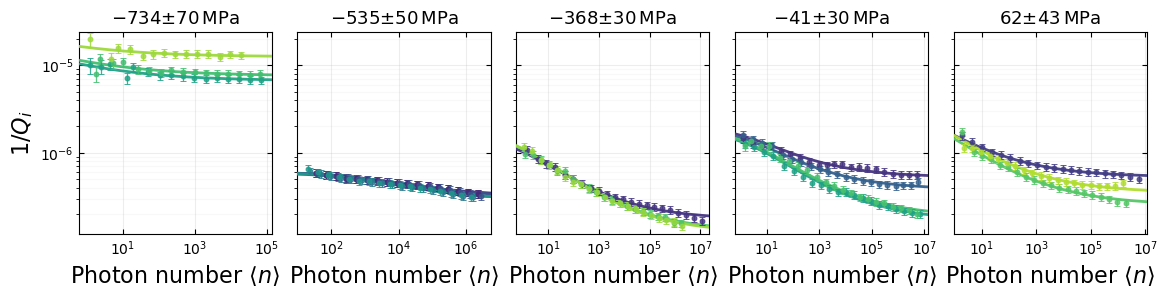

In [10]:
fig = plot_power_sweep_fits_5col(
    power_results,
    figsize=(15.5*.75, 3.9*.75),
    cmap_name="viridis",
    plot_loss=True,
    savepath="tls_saturation.pdf",
)

plt.show()

In [11]:
power_results['Sample A']['data']['f_res'].unique()

array([5.45667568e+09, 5.77765468e+09, 6.19093884e+09])

In [12]:
list(power_results['Sample A']['data'].groupby("res_id"))

[('Sample A::Res2',
        sample label          res_id  stress  stress_err         n         Qi  \
  0   Sample A  Res2  Sample A::Res2  -734.0          70      1.21  100031.31   
  1   Sample A  Res2  Sample A::Res2  -734.0          70      2.47  103682.77   
  2   Sample A  Res2  Sample A::Res2  -734.0          70      4.53   96314.35   
  3   Sample A  Res2  Sample A::Res2  -734.0          70     13.40  140906.04   
  4   Sample A  Res2  Sample A::Res2  -734.0          70     19.70  105207.29   
  5   Sample A  Res2  Sample A::Res2  -734.0          70     49.60  119787.54   
  6   Sample A  Res2  Sample A::Res2  -734.0          70    109.00  130701.76   
  7   Sample A  Res2  Sample A::Res2  -734.0          70    217.00  129767.52   
  8   Sample A  Res2  Sample A::Res2  -734.0          70    462.00  134560.93   
  9   Sample A  Res2  Sample A::Res2  -734.0          70    980.00  138917.60   
  10  Sample A  Res2  Sample A::Res2  -734.0          70   2050.00  141979.39   
  11  Sa

In [13]:
# ---------------------------------------------------------------------
# Paper-style power sweep figure:
#   top row: Q_i vs photon number
#   bottom row: normalized TLS saturation fraction
# ---------------------------------------------------------------------

def plot_power_sweep_fits_with_tls_fraction(
    power_results,
    figsize=(15.5, 6.4),
    cmap_name="viridis",
    n_fit_points=1000,
    savepath=None,
    ylims_Qi=(5e4, 6e6),
    ylims_frac=(3e-3, 2.0),
    xlims=(0.5, 2e7),
    n_temp_range=None,   # e.g. (1e5, 1e6)
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    samples = sorted(
        power_results.keys(),
        key=lambda s: _result_stress(power_results[s]),
    )

    fig, axs = plt.subplots(
        2,
        len(samples),
        figsize=figsize,
        sharex=False,
        sharey="row",
        squeeze=False,
        constrained_layout=False,
    )

    cmap = mpl.colormaps[cmap_name]

    title_fs = 15
    label_fs = 15
    tick_fs = 12
    legend_fs = 9
    ms = 4.2
    lw = 2.2

    for i, sample in enumerate(samples):
        result = power_results[sample]
        df_s = result["data"]
        tls = result["tls_saturation"]

        axQ = axs[0, i]
        axF = axs[1, i]

        res_groups = list(df_s.groupby("res_id"))
        colors = cmap(np.linspace(0.12, 0.88, len(res_groups)))

        nplot = np.logspace(
            np.log10(df_s["n"].min()),
            np.log10(df_s["n"].max()),
            n_fit_points,
        )

        for color, (res_id, df_r) in zip(colors, res_groups):
            df_r = df_r.sort_values("n")
            label = res_id.split("::")[-1]

            Cj = tls["C_res"][res_id]
            A = tls["A_TLS"]
            f_res = df_r["f_res"].median()
            th = tls_tanh_factor(T_BASE_POWER, f_res)

            sat_fit = tls_saturation_shape(
                nplot,
                np.log10(tls["nc"]),
                beta=tls["beta"],
            )

            y_invQ_fit = Cj + A * th * sat_fit
            y_Q_fit = 1.0 / y_invQ_fit

            # Raw Qi data
            Qi_data = df_r["Qi"].to_numpy(float)
            Qi_err = df_r["Qi_err"].to_numpy(float)

            good_Q = (
                np.isfinite(df_r["n"])
                & np.isfinite(Qi_data)
                & np.isfinite(Qi_err)
                & (df_r["n"] > 0)
                & (Qi_data > 0)
                & (Qi_err > 0)
            )

            axQ.errorbar(
                df_r.loc[good_Q, "n"],
                Qi_data[good_Q],
                yerr=Qi_err[good_Q],
                fmt="o",
                ms=ms,
                capsize=2.0,
                color=color,
                ecolor=color,
                elinewidth=1.0,
                markeredgewidth=0.7,
                alpha=0.88,
                label=label,
                zorder=5,
            )

            axQ.plot(
                nplot,
                y_Q_fit,
                "-",
                lw=lw,
                color=color,
                alpha=0.95,
                zorder=4,
            )

            # Normalized TLS fraction:
            #   F_TLS = (delta - Cj)/(A_TLS * tanh)
            invQ_data = df_r["invQ"].to_numpy(float)
            invQ_err = df_r["invQ_err"].to_numpy(float)

            denom = A * th
            frac_data = (invQ_data - Cj) / denom
            frac_err = invQ_err / denom

            good_F = (
                np.isfinite(df_r["n"])
                & np.isfinite(frac_data)
                & np.isfinite(frac_err)
                & (df_r["n"] > 0)
                & (frac_data > 0)
                & (frac_err > 0)
            )

            axF.errorbar(
                df_r.loc[good_F, "n"],
                frac_data[good_F],
                yerr=frac_err[good_F],
                fmt="o",
                ms=ms,
                capsize=2.0,
                color=color,
                ecolor=color,
                elinewidth=1.0,
                markeredgewidth=0.7,
                alpha=0.88,
                zorder=5,
            )

            axF.plot(
                nplot,
                sat_fit,
                "-",
                lw=lw,
                color=color,
                alpha=0.95,
                zorder=4,
            )

        stress = df_s["stress"].iloc[0]

        axQ.set_title(
            f"{sample}\n{stress:+.0f} MPa",
            fontsize=title_fs,
            pad=6,
        )

        for ax in (axQ, axF):
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_xlim(xlims)

            if n_temp_range is not None:
                ax.axvspan(
                    n_temp_range[0],
                    n_temp_range[1],
                    color="0.8",
                    alpha=0.25,
                    zorder=0,
                )

            ax.grid(True, which="major", alpha=0.22)
            ax.grid(True, which="minor", alpha=0.08)
            ax.tick_params(
                axis="both",
                labelsize=tick_fs,
                direction="in",
                top=True,
                right=True,
            )

        axQ.set_ylim(ylims_Qi)
        axF.set_ylim(ylims_frac)

        if i == 0:
            axQ.set_ylabel(r"$Q_i$", fontsize=label_fs)
            axF.set_ylabel(
                r"TLS fraction $(\delta-C_j)/(A_{\rm TLS}\tanh)$",
                fontsize=label_fs,
            )

        axF.set_xlabel(
            r"Photon number $\langle n\rangle$",
            fontsize=label_fs,
        )

        if sample == "Sample B" or ("Sample B" not in samples and i == 0):
            axQ.legend(
                fontsize=legend_fs,
                ncol=1,
                frameon=True,
                handlelength=1.3,
                borderpad=0.35,
                loc="best",
            )

    fig.subplots_adjust(
        left=0.065,
        right=0.995,
        bottom=0.12,
        top=0.88,
        wspace=0.18,
        hspace=0.18,
    )

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig

In [14]:
# ---------------------------------------------------------------------
# Collapsed TLS saturation plot
# ---------------------------------------------------------------------

def plot_tls_saturation_collapse(
    power_results,
    figsize=(5.2, 4.0),
    cmap_name="plasma",
    n_fit_points=1000,
    beta_ref=None,
    n_temp_range=None,  # e.g. (1e5, 1e6), shown as range in n/nc approximately if using median nc
    savepath=None,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    samples = sorted(
        power_results.keys(),
        key=lambda s: _result_stress(power_results[s]),
    )

    stresses = np.array([
        _result_stress(power_results[s])
        for s in samples
    ])

    norm = mpl.colors.Normalize(
        vmin=np.nanmin(stresses),
        vmax=np.nanmax(stresses),
    )
    cmap = mpl.colormaps[cmap_name]

    fig, ax = plt.subplots(figsize=figsize)

    all_beta = []
    all_nc = []

    for sample in samples:
        result = power_results[sample]
        df_s = result["data"]
        tls = result["tls_saturation"]

        stress = _result_stress(result)
        color = cmap(norm(stress))

        A = tls["A_TLS"]
        nc = tls["nc"]
        beta = tls["beta"]

        all_beta.append(beta)
        all_nc.append(nc)

        for res_id, df_r in df_s.groupby("res_id"):
            df_r = df_r.sort_values("n")

            Cj = tls["C_res"][res_id]
            f_res = df_r["f_res"].median()
            th = tls_tanh_factor(T_BASE_POWER, f_res)

            x = df_r["n"].to_numpy(float) / nc
            y = (df_r["invQ"].to_numpy(float) - Cj) / (A * th)
            yerr = df_r["invQ_err"].to_numpy(float) / (A * th)

            good = (
                np.isfinite(x)
                & np.isfinite(y)
                & np.isfinite(yerr)
                & (x > 0)
                & (y > 0)
                & (yerr > 0)
            )

            ax.errorbar(
                x[good],
                y[good],
                yerr=yerr[good],
                fmt="o",
                ms=3.5,
                capsize=1.6,
                color=color,
                ecolor=color,
                alpha=0.55,
                elinewidth=0.8,
                markeredgewidth=0.6,
                zorder=4,
            )

    if beta_ref is None:
        beta_ref = float(np.nanmedian(all_beta))

    xplot = np.logspace(-5, 7, n_fit_points)
    yplot = 1.0 / np.sqrt(1.0 + xplot**beta_ref)

    ax.plot(
        xplot,
        yplot,
        color="black",
        lw=2.4,
        zorder=6,
        label=rf"$[1+(\langle n\rangle/n_c)^{{\beta}}]^{{-1/2}}$, $\beta={beta_ref:.2g}$",
    )

    # ax.axvline(
    #     1.0,
    #     color="0.35",
    #     ls="--",
    #     lw=1.0,
    #     zorder=2,
    # )

    # ax.text(
    #     1.1,
    #     1.2,
    #     r"$\langle n\rangle=n_c$",
    #     fontsize=10,
    #     rotation=90,
    #     va="top",
    #     ha="left",
    # )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(
        r"Scaled photon number $\langle n\rangle/n_c$",
        fontsize=12,
    )
    ax.set_ylabel(
        r"$[1/Q_i(\langle n\rangle)-\delta_0]/\delta_\mathrm{TLS}$",
        fontsize=12,
    )

    ax.set_xlim(1e-5, 1e7)
    ax.set_ylim(2e-3, 3)

    ax.grid(True, which="major", alpha=0.24)
    ax.grid(True, which="minor", alpha=0.08)

    ax.tick_params(
        axis="both",
        labelsize=10,
        direction="in",
        top=True,
        right=True,
    )

    ax.legend(
        fontsize=9,
        frameon=True,
        loc="lower left", framealpha=1,
    )

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Stress [MPa]", fontsize=11)
    cbar.ax.tick_params(labelsize=9)

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig

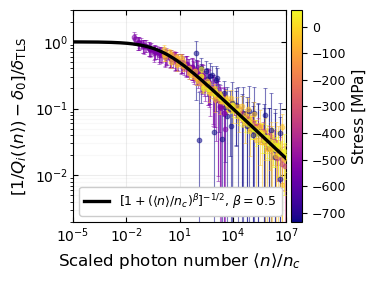

In [15]:
fig = plot_tls_saturation_collapse(
    power_results,
    figsize=(5.2*.75, 4.0*.75),
    cmap_name="plasma",
    savepath="tls_saturation_collapse.png",
)

plt.show()

In [18]:
# ---------------------------------------------------------------------
# Collapsed TLS saturation plot with approximate temperature-sweep band
# ---------------------------------------------------------------------

def plot_tls_saturation_collapse(
    power_results,
    figsize=(5.2, 4.0),
    cmap_name="plasma",
    n_fit_points=1000,
    beta_ref=None,
    temp_photon_ranges=None,
    temp_band_percentiles=(5, 95),
    savepath=None,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    samples = sorted(
        power_results.keys(),
        key=lambda s: _result_stress(power_results[s]),
    )

    stresses = np.array([
        _result_stress(power_results[s])
        for s in samples
    ])

    norm = mpl.colors.Normalize(
        vmin=np.nanmin(stresses),
        vmax=np.nanmax(stresses),
    )
    cmap = mpl.colormaps[cmap_name]

    fig, ax = plt.subplots(figsize=figsize)

    all_beta = []
    all_nc = []

    # ------------------------------------------------------------
    # Approximate photon-number ranges during temperature sweeps
    # estimated from JT's Fig. S4.
    #
    # These are intentionally rough. Replace with actual values
    # once the temperature-sweep photon-number dataframe is available.
    # ------------------------------------------------------------
    if temp_photon_ranges is None:
        temp_photon_ranges = {
            "Sample A": (7, 1.5e3),
            "Sample B": (6e1, 5e4),
            "Sample C": (1e2, 2.2e5),
            "Sample D": (6e1, 1.4e5),
            "Sample E": (1e4, 8e4),
        }

    x_temp_vals = []

    # ------------------------------------------------------------
    # Plot normalized TLS-collapse data
    # ------------------------------------------------------------
    for sample in samples:
        result = power_results[sample]
        df_s = result["data"]
        tls = result["tls_saturation"]

        stress = _result_stress(result)
        color = cmap(norm(stress))

        A = tls["A_TLS"]
        nc = tls["nc"]
        beta = tls["beta"]

        all_beta.append(beta)
        all_nc.append(nc)

        # Convert approximate temperature-sweep photon-number range
        # into collapsed coordinate n/nc.
        if sample in temp_photon_ranges:
            nlo, nhi = temp_photon_ranges[sample]
            x_temp_vals.extend([nlo / nc, nhi / nc])

        for res_id, df_r in df_s.groupby("res_id"):
            df_r = df_r.sort_values("n")

            Cj = tls["C_res"][res_id]
            f_res = df_r["f_res"].median()
            th = tls_tanh_factor(T_BASE_POWER, f_res)

            x = df_r["n"].to_numpy(float) / nc
            y = (df_r["invQ"].to_numpy(float) - Cj) / (A * th)
            yerr = df_r["invQ_err"].to_numpy(float) / (A * th)

            good = (
                np.isfinite(x)
                & np.isfinite(y)
                & np.isfinite(yerr)
                & (x > 0)
                & (y > 0)
                & (yerr > 0)
            )

            ax.errorbar(
                x[good],
                y[good],
                yerr=yerr[good],
                fmt="o",
                ms=3.5,
                capsize=1.6,
                color=color,
                ecolor=color,
                alpha=0.55,
                elinewidth=0.8,
                markeredgewidth=0.6,
                zorder=4,
            )

    # ------------------------------------------------------------
    # Shaded temperature-sweep region in n/nc
    # ------------------------------------------------------------
    x_temp_vals = np.asarray(x_temp_vals, dtype=float)
    x_temp_vals = x_temp_vals[np.isfinite(x_temp_vals) & (x_temp_vals > 0)]

    if len(x_temp_vals):
        xlo, xhi = np.nanpercentile(x_temp_vals, temp_band_percentiles)
        xmed = np.nanmedian(x_temp_vals)

        ax.axvspan(
            xlo,
            xhi,
            color="0.85",
            alpha=0.45,
            zorder=0,
        )

        # ax.text(
        #     xmed,
        #     0.025,
        #     "temperature\nsweeps",
        #     ha="center",
        #     va="bottom",
        #     fontsize=8,
        #     color="0.25",
        #     zorder=20,
        # )

    # ------------------------------------------------------------
    # Universal TLS saturation model
    # ------------------------------------------------------------
    if beta_ref is None:
        beta_ref = float(np.nanmedian(all_beta))

    xplot = np.logspace(-5, 7, n_fit_points)
    yplot = 1.0 / np.sqrt(1.0 + xplot**beta_ref)

    ax.plot(
        xplot,
        yplot,
        color="black",
        lw=2.4,
        zorder=6,
        label=rf"$[1+(\langle n\rangle/n_c)^{{\beta}}]^{{-1/2}}$, $\beta={beta_ref:.2g}$",
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(
        r"Scaled photon number $\langle n\rangle/n_c$",
        fontsize=12,
    )
    ax.set_ylabel(
        r"$[1/Q_i(\langle n\rangle)-\delta_0]/\delta_\mathrm{TLS}$",
        fontsize=12,
    )

    ax.set_xlim(1e-5, 1e7)
    ax.set_ylim(2e-3, 3)

    ax.grid(True, which="major", alpha=0.24)
    ax.grid(True, which="minor", alpha=0.08)

    ax.tick_params(
        axis="both",
        labelsize=10,
        direction="in",
        top=True,
        right=True,
    )

    ax.legend(
        fontsize=9,
        frameon=True,
        loc="lower left",
        framealpha=1,
    )

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Stress [MPa]", fontsize=11)
    cbar.ax.tick_params(labelsize=9)

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig

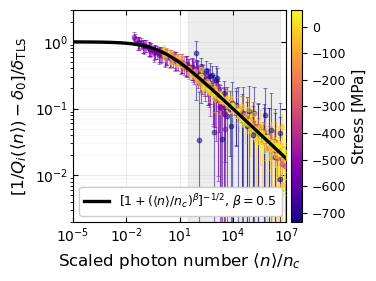

In [19]:
fig = plot_tls_saturation_collapse(
    power_results,
    figsize=(5.2*.75, 4.0*.75),
    cmap_name="plasma",
    temp_band_percentiles=(5, 95),
    savepath="saturation_collapse.pdf",
)

plt.show()